In [9]:
"""Smoke-test for the Rossmann store sales forecasting pipeline.

Generates a small synthetic dataset with a strong, easy-to-fit weekly pattern,
runs the full feature-engineering → nested CV pipeline, prints test-set metrics,
and plots real vs predicted sales for the last outer fold.

Usage: conda run -n rossmann python test_pipeline.py
"""

import os
import logging
import warnings

import optuna
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import src.constants as C

from matplotlib import cm
from src.features import make_features, make_targets, attach_store_data
from src.preprocessing import drop_null_targets
from src.engine.cv import TimeSeriesCV
from src.engine.metrics import compute_metrics
from src.engine import utils, hypertuning

from src import synthetic

FORECAST_HORIZON = 5

os.makedirs(C.LOG_DIR, exist_ok=True)
logging.basicConfig(level=logging.INFO, 
                    filename=os.path.join(C.LOG_DIR, "test_pipeline.log"),
                    format="%(levelname)s  %(message)s")
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

logger = logging.getLogger(__name__)



from pandas.tseries.offsets import DateOffset


def split_Xy(df, forecast_horizon):
    """Split a dataframe into features X and targets y.

    Closed-day sales (zeros) are first replaced by interpolated values so that
    lag/rolling features can be computed across those days.  The Sales column is
    then differenced with a lag of ``forecast_horizon``, so each target value is:

        y[t] = interpolated_sales[t + forecast_horizon] - interpolated_sales[t]

    i.e. the ``forecast_horizon``-step-ahead *change* in (interpolated) sales.

    Features are then generated from the differenced sales using the same lags,
    rolling windows, and differences plus store-related features.
    """

    sales_interp = utils.overwrite_closed_sales(df['Sales'], mode='interpolate')
    df['Sales'] = sales_interp.groupby(level='Store').diff(periods=forecast_horizon)

    X = make_features(df, C.LAGS, C.ROLL_WINDOWS, C.DIFFS)
    y = make_targets(df['Sales'], forecast_horizon)
    X, y = drop_null_targets(X, y)
    
    return X, y



# Synthetic Data

Strong deterministic weekly + trend signal so the model can overfit easily and produce low errors.

 DayOfWeek  Open  Promo StateHoliday  SchoolHoliday      Sales StoreType Assortment  CompetitionDistance CompetitionSinceDate Promo2SinceDate  Promo2
         2     1      0            0              0 467.320508         a          a                500.0           2012-04-01      2012-07-01       1
         2     1      0            0              0 617.320508         b          a                850.0           2012-07-01             NaT       0
         2     1      0            0              0 767.320508         c          b               1200.0           2012-10-01      2013-07-01       0
         3     1      0            0              0 467.820508         a          a                500.0           2012-04-01      2012-07-01       1
         3     1      0            0              0 618.320508         b          a                850.0           2012-07-01             NaT       0


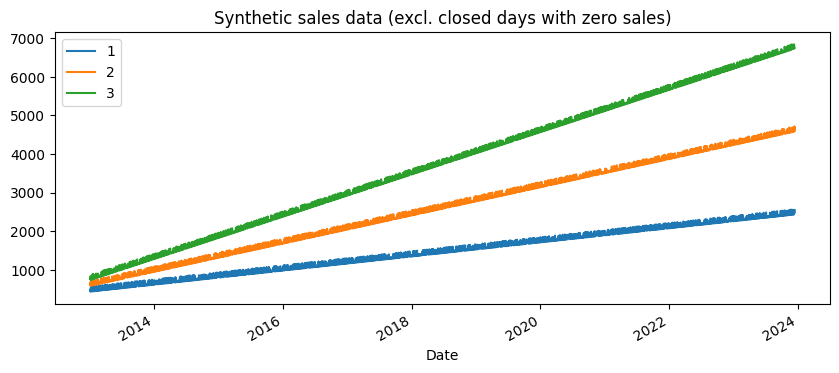

In [10]:
stores = synthetic.store_data()
train = synthetic.sales_data()
df  = attach_store_data(train, stores)
df.sort_values(['Date', 'Store'], inplace=True)  # Sort by date and store (ascending -> from earliest to latest) for lag features
df.set_index(["Date", "Store"], inplace=True)

cv_config = {
    "n_outer_splits":   C.N_OUTER_SPLITS,
    "n_inner_splits":   C.N_INNER_SPLITS,
    "forecast_horizon": FORECAST_HORIZON, #C.FORECAST_HORIZON,
    "inner_train_size": 1000, #C.INNER_TRAIN_SIZE,
}

cv_config["outer_train_size"] = (cv_config["n_inner_splits"] + 1) * cv_config["forecast_horizon"] + cv_config["inner_train_size"]


study_config = {
    "storage_url":           C.STORAGE_URL,
    "n_trials":              C.NUM_TRIALS,
    "n_startup_trials":      C.NUM_STARTUP_TRIALS,
    "n_jobs":                C.NUM_JOBS,
    "seed":                  C.SEED,
    "xgb_constants":         C.XGB_CONSTANTS,
    "early_stopping_rounds": C.EARLY_STOPPING_ROUNDS,
    "num_boost_rounds":      C.NUM_BOOST_ROUNDS,
    "monitor_periods":       C.MONITOR_PERIODS,
    "hyperparameters":       C.HYPERPARAMETERS,
    "log_dir":               C.LOG_DIR,
}

print(df.head(5).to_string(index=False))

(
    df
    .loc[df['Sales'] > 0]
    .reset_index()
    .set_index("Date")
    .groupby("Store")["Sales"]
    .plot(figsize=(10, 4),
          title="Synthetic sales data (excl. closed days with zero sales)",
          legend=True)
)

plt.savefig(os.path.join(C.LOG_DIR, "training_set.png"))

In [11]:
""" 
# Preprocessing steps:
# 1. Overwrite zero sales for Sundays (closed) with interpolated values based on adjacent open days, 
#    to allow feature creation for those days (e.g. lags, rolls, diffs, forecast horizon)
# 2. First-order differencing on the Sales column to make the series more stationary
# 3. Create features and targets for the whole dataset
# 4. Drop rows with null targets (i.e. those that don't have enough history
#    to create all requested lags, rolls, diffs, and/or forecast horizon)

df_processed = df.copy()
df_processed['Sales'] = (
    utils.overwrite_closed_sales(df_processed['Sales'], mode='interpolate')
    .groupby(level='Store')
    .diff()
)
X = make_features(df_processed, lags, rolling_windows, diffs)
y = make_targets(df_processed['Sales'], FORECAST_HORIZON)
X, y = drop_null_targets(X, y)

cv = TimeSeriesCV(n_splits=cv_config["n_outer_splits"],
                  horizon=cv_config["forecast_horizon"],
                  train_size=cv_config["outer_train_size"])

for fold, (train_ix, test_ix) in enumerate(cv.split(X, y), start=1):
    logger.info(f"Outer fold {fold}/{cv_config['n_outer_splits']} starting...")

    study_name = f"fold_{fold}"
    X_train, y_train = X.iloc[train_ix], y.iloc[train_ix]
    X_test, y_test = X.iloc[test_ix], y.iloc[test_ix]
    
    # Run Optuna hyperparameter tuning with nested CV in the inner loop
    logger.info(f"Running hyperparameter tuning ({study_config['n_trials']} trials)...")
    hypertuning.optimize(study_name, X_train, y_train, {**cv_config, **study_config})

    # Retrain final model on the entire outer fold training set with the best hyperparameters
    logger.info(f"Retraining model with the best hyperparameters...")
    study = optuna.load_study(study_name=study_name, storage=study_config["storage_url"])
    booster = hypertuning.refit(X_train, y_train, study.best_trial, study_config)
    
    logger.info(f"Evaluating final model on outer fold {fold} test set...")
    preds = utils.predict(booster, X_test)

    # Inverse first-order differencing to get predictions back on the original scale
    origin_index = preds.index.droplevel('Forecast Date')
    anchors = (utils.overwrite_closed_sales(df['Sales'], mode='interpolate')
               .loc[origin_index]
               .set_axis(preds.index))
    preds = anchors + preds.groupby(level=['Date', 'Store']).cumsum()
    
    # Log metrics and artifacts
    actuals = utils.retrieve_sales(df['Sales'], preds.index)
    metrics = compute_metrics(actuals.values, preds.values)
    logger.info(f"Test set metrics for fold {fold}: {metrics}")
    
    booster_file = os.path.join(study_config["log_dir"], study_name, "model.ubj")
    preds_file = os.path.join(study_config["log_dir"], study_name, "predictions.csv")
    booster.save_model(booster_file)
    preds.to_csv(preds_file)

    break
"""

' \n# Preprocessing steps:\n# 1. Overwrite zero sales for Sundays (closed) with interpolated values based on adjacent open days, \n#    to allow feature creation for those days (e.g. lags, rolls, diffs, forecast horizon)\n# 2. First-order differencing on the Sales column to make the series more stationary\n# 3. Create features and targets for the whole dataset\n# 4. Drop rows with null targets (i.e. those that don\'t have enough history\n#    to create all requested lags, rolls, diffs, and/or forecast horizon)\n\ndf_processed = df.copy()\ndf_processed[\'Sales\'] = (\n    utils.overwrite_closed_sales(df_processed[\'Sales\'], mode=\'interpolate\')\n    .groupby(level=\'Store\')\n    .diff()\n)\nX = make_features(df_processed, lags, rolling_windows, diffs)\ny = make_targets(df_processed[\'Sales\'], FORECAST_HORIZON)\nX, y = drop_null_targets(X, y)\n\ncv = TimeSeriesCV(n_splits=cv_config["n_outer_splits"],\n                  horizon=cv_config["forecast_horizon"],\n                  train_s

In [ ]:
import xgboost as xgb
from src.engine import utils
from src.engine.hypertuning import _objective
from optuna.trial import FixedTrial

FORECAST_HORIZON = 10
NUM_STORES = 4
NUM_DAYS = 365*4

stores = synthetic.store_data(n_stores=NUM_STORES)
sales = synthetic.sales_data(n_stores=NUM_STORES, days=NUM_DAYS)

df  = (attach_store_data(sales, stores)
       .sort_values(['Date', 'Store'])  # Sort by date and store (ascending -> from earliest to latest) for lag features
       .set_index(["Date", "Store"]))

X, y = split_Xy(df.copy(), FORECAST_HORIZON)

inner_cv = TimeSeriesCV(n_splits=C.N_INNER_SPLITS,
                        train_size=C.INNER_TRAIN_SIZE,
                        test_size=C.INNER_TEST_SIZE)

params = {
'max_depth': 6,
'learning_rate': 1e-3,
'subsample': 0.3,
'colsample_bytree': 0.3,
'min_child_weight': 1,
'reg_alpha': 0.1,
'reg_lambda': 0.1,
'gamma': 0.1,
}

mock_trial = FixedTrial(params)
obj_fcn = lambda trial: _objective(trial, X, y, inner_cv,
                                study_name='stuff',
                                study_config=study_config)

obj_fcn(mock_trial)

[0]	train-rmse:66.09479+0.31617	test-rmse:67.53792+0.90173
[100]	train-rmse:62.32685+0.28140	test-rmse:64.14189+0.86255
[200]	train-rmse:59.03618+0.25451	test-rmse:61.25409+0.84163
[300]	train-rmse:56.06253+0.23953	test-rmse:58.69751+0.85598
[400]	train-rmse:53.39142+0.22419	test-rmse:56.49112+0.85251
[500]	train-rmse:50.99793+0.20312	test-rmse:54.56812+0.86634
[600]	train-rmse:48.84189+0.19120	test-rmse:52.88492+0.86939
[700]	train-rmse:46.91823+0.18224	test-rmse:51.43496+0.89436
[800]	train-rmse:45.18762+0.17957	test-rmse:50.18190+0.92639
[900]	train-rmse:43.64303+0.17357	test-rmse:49.11406+0.95256
[1000]	train-rmse:42.24722+0.17330	test-rmse:48.20056+0.98827
[1100]	train-rmse:40.98866+0.17920	test-rmse:47.43872+1.02883
[1200]	train-rmse:39.85916+0.18182	test-rmse:46.79832+1.06022
[1300]	train-rmse:38.84621+0.18094	test-rmse:46.28023+1.08061
[1400]	train-rmse:37.91678+0.18105	test-rmse:45.82270+1.12156
[1500]	train-rmse:37.06383+0.17489	test-rmse:45.42513+1.16288
[1600]	train-rmse:36

np.float64(43.651472025688385)

In [13]:
booster = hypertuning.refit(X, y, mock_trial, study_config)

test_dmatrix  = xgb.DMatrix(X, enable_categorical=True)
diff_preds = booster.predict(test_dmatrix)
diff_preds = pd.Series(data=diff_preds, index=X.index)

# Inverse first-order differencing to get predictions back on the original scale
# diff_preds[t] = sales[t + FORECAST_HORIZON] - sales[t], so:
# preds[t] = diff_preds[t] + interpolated_sales[t]
anchors = utils.overwrite_closed_sales(df['Sales'].copy(), mode='interpolate').loc[diff_preds.index]
preds = anchors + diff_preds
preds = utils.overwrite_closed_sales(preds, mode='zero')

actuals = df.loc[preds.index, 'Sales']

In [14]:
max_date = actuals.index.get_level_values("Date").max()
min_date = max_date - pd.Timedelta(days=90)
actuals_recent = actuals.loc[(slice(min_date, max_date), slice(None))]
preds_recent = preds.loc[(slice(min_date, max_date), slice(None), slice(None))]

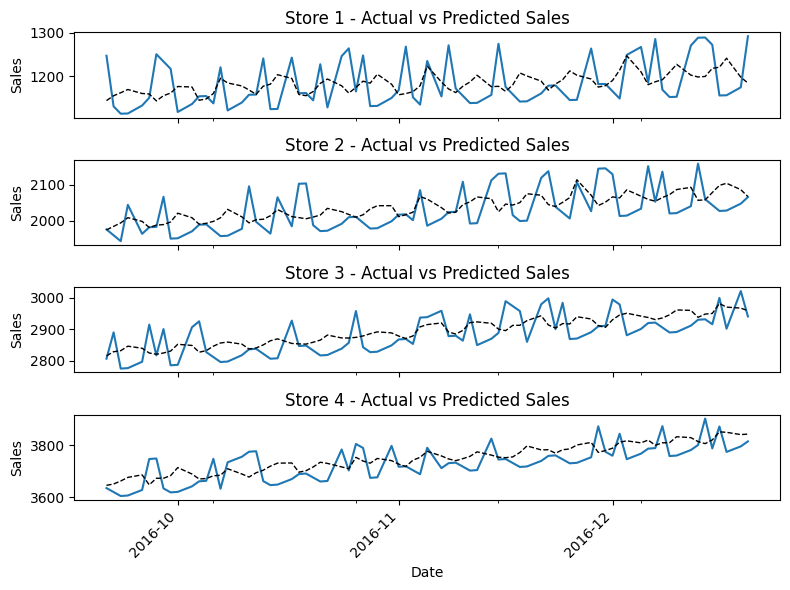

In [15]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


actuals = df.loc[preds.index, 'Sales']
actuals_small = actuals.iloc[:1200]
preds_small = preds.iloc[:1200]


stores = actuals_recent.index.get_level_values("Store").unique()
fig, ax = plt.subplots(figsize=(8, 6), nrows=len(stores), sharex=True, sharey=False)

for i, store in enumerate(stores):

    actual_store_sales = (actuals_recent
                        .loc[(slice(None), store)]
                        .sort_index())
    
    predicted_store_sales = (preds_recent
                            .loc[(slice(None), store, slice(None))]
                            .reset_index())

    # exclude closed days with zero sales and zero predictions
    actual_store_sales = actual_store_sales[actual_store_sales > 0]
    predicted_store_sales = predicted_store_sales[predicted_store_sales[0] > 0]

    actual_store_sales.plot(label=f"Store {store}", ax=ax[i])
    (predicted_store_sales
    #.groupby("Date")
    .plot(x="Date", y=0, ax=ax[i], color='k', linestyle='--', linewidth=1))

    ax[i].get_legend().remove()
    ax[i].set_title(f"Store {store} - Actual vs Predicted Sales")
    ax[i].set_ylabel("Sales")
    
# Rotate x labels and set date format
ax[-1].xaxis.set_major_locator(mdates.MonthLocator())
ax[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
ax[-1].set_xlabel("Date")
plt.tight_layout()

In [16]:
stores = synthetic.store_data(n_stores=NUM_STORES)
train = synthetic.sales_data(n_stores=NUM_STORES, days=NUM_DAYS)
df  = attach_store_data(train, stores)
df.sort_values(['Date', 'Store'], inplace=True)  # Sort by date and store (ascending -> from earliest to latest) for lag features
df.set_index(["Date", "Store"], inplace=True)
X = make_features(df, C.LAGS, C.ROLL_WINDOWS, C.DIFFS)

forecast_horizon = 10
y = make_targets(df['Sales'], forecast_horizon)

# sales for store 1
store1 = df.index.get_level_values("Store") == 1
df_sales = df.loc[store1, "Sales"]
df_sales.name = "original_sales"

# features for store 1
store1 = X.index.get_level_values("Store") == 1
top_cols = [c for c in X.columns if 'lag' in c][:5]
x_sales = X.loc[store1, top_cols]
x_sales.columns = [f"feature_{col}" for col in x_sales.columns]

# targets for store 1
store1 = y.index.get_level_values("Store") == 1
ystore = y.loc[store1]
ystore.name = f"Target_horizon_{forecast_horizon}"

pd.concat([df_sales, x_sales, ystore], axis=1).head(30)

,,original_sales,feature_lag_1_days,feature_lag_2_days,feature_lag_3_days,feature_lag_4_days,feature_lag_5_days,Target_horizon_10
Date,Store,,,,,,,
2013-01-01,1,467.320508,NaN,NaN,NaN,NaN,NaN,437.679492
2013-01-02,1,467.820508,467.320508,NaN,NaN,NaN,NaN,438.179492
2013-01-03,1,451.000000,467.820508,467.320508,NaN,NaN,NaN,0.000000
2013-01-04,1,434.179492,451.000000,467.820508,467.320508,NaN,NaN,456.500000
2013-01-05,1,534.679492,434.179492,451.000000,467.820508,467.320508,NaN,474.320508
2013-01-06,1,0.000000,534.679492,434.179492,451.000000,467.820508,467.320508,574.820508
2013-01-07,1,453.000000,0.000000,534.679492,434.179492,451.000000,467.820508,458.000000
2013-01-08,1,470.820508,453.000000,0.000000,534.679492,434.179492,451.000000,541.179492
2013-01-09,1,571.320508,470.820508,453.000000,0.000000,534.679492,434.179492,441.679492


In [90]:
predicted_store_sales

,Date,Forecast Date,0
0,2016-09-27,2016-09-28,1226.649998
1,2016-09-28,2016-09-29,1226.371926
2,2016-09-29,2016-09-30,1111.006675
3,2016-09-30,2016-10-01,1089.886573
4,2016-10-01,2016-10-02,1088.029492
...,...,...,...
85,2016-12-21,2016-12-22,1141.493492
86,2016-12-22,2016-12-23,1123.633712
87,2016-12-23,2016-12-24,1100.427859
88,2016-12-24,2016-12-25,1100.629492
